# Notebook 03_C: Final Model Selection

This notebook selects and freezes the final prediction model.

Only the two strongest models from Notebook 03_B are continued:

- Random Forest
- XGBoost

The workflow is intentionally limited:

1. Create an internal development and validation split from the training set.
2. Perform light tuning for Random Forest and XGBoost using development data only.
3. Calibrate the tuned models.
4. Analyse decision thresholds using the internal validation set.
5. Select and freeze one final model and threshold.
6. Refit the frozen model on the full training set.
7. Evaluate the frozen model on the held out test set.
8. Evaluate gender fairness on the held out test set.
9. Save only the final model and essential results.


## 1. Imports and project paths

In [1]:
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

RANDOM_STATE = 42
CV_RANDOM_STATE = 2026

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "ml_ready"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
    / "final_model"
)

FIGURES_DIR = (
    PROJECT_DIR
    / "results"
    / "figures"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)

Project directory: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks


## 2. Load raw train, test, and fairness data

The held out test set is loaded here but is not used during tuning, calibration, threshold selection, or model selection.

Notebook 03_A previously used the test set only for descriptive baseline reporting. All optimisation decisions in this notebook use training data only.

In [2]:
X_train = pd.read_pickle(
    DATA_DIR / "X_train_raw.pkl"
)

X_test = pd.read_pickle(
    DATA_DIR / "X_test_raw.pkl"
)

y_train = pd.read_pickle(
    DATA_DIR / "y_train.pkl"
)

y_test = pd.read_pickle(
    DATA_DIR / "y_test.pkl"
)

fairness_test = pd.read_pickle(
    DATA_DIR / "fairness_test.pkl"
)

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert len(fairness_test) == len(y_test)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Fairness shape:", fairness_test.shape)

Training shape: (3008, 24)
Testing shape: (752, 24)
Fairness shape: (752, 1)


## 3. Create internal development and validation sets

The original 3,008 training students are split again:

- 80% development data for light tuning
- 20% internal validation data for calibration assessment, threshold analysis, and final candidate selection

The held out test set is not used until the final model and threshold are frozen.

In [3]:
X_dev, X_valid, y_dev, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

print("Development shape:", X_dev.shape)
print("Validation shape:", X_valid.shape)

print(
    "Development at risk percentage:",
    round(float(y_dev.mean() * 100), 2),
)

print(
    "Validation at risk percentage:",
    round(float(y_valid.mean() * 100), 2),
)


Development shape: (2406, 24)
Validation shape: (602, 24)
Development at risk percentage: 24.81
Validation at risk percentage: 24.75


In [4]:
scale_pos_weight = (y_dev == 0).sum() / (y_dev == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 3))

scale_pos_weight: 3.03


## 4. Define preprocessing

In [5]:
CATEGORICAL_FEATURES = [
    "programme_or_school",
    "year_level",
    "previous_academic_standing",
]

NUMERIC_FEATURES = [
    column
    for column in X_train.columns
    if column not in CATEGORICAL_FEATURES
]

assert len(NUMERIC_FEATURES) == 21
assert len(CATEGORICAL_FEATURES) == 3
assert X_train.shape[1] == 24

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
    (
        "scaler",
        StandardScaler(),
    ),
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent"),
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore"),
    ),
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        NUMERIC_FEATURES,
    ),
    (
        "categorical",
        categorical_pipeline,
        CATEGORICAL_FEATURES,
    ),
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=CV_RANDOM_STATE,
)

print("Raw predictors locked:", X_train.shape[1])

Raw predictors locked: 24


## 5. Light tuning

Only a small random search is used.

Eight parameter combinations are evaluated for each finalist using five fold stratified cross validation on the development data.

F1 is used for tuning because it balances precision and recall. Recall is prioritised later during threshold selection using F2.

In [6]:


rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor,
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
    ),
])

rf_parameters = {
    "model__n_estimators": [250, 350, 500],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_leaf": [1, 3, 5],
    "model__max_features": ["sqrt", 0.7],
    "model__class_weight": ["balanced", {0: 1, 1: 3}],
}

xgb_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor,
    ),
    (
        "model",
        XGBClassifier(
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
    ),
])

xgb_parameters = {
    "model__n_estimators": [200, 300, 450],
    "model__learning_rate": [0.03, 0.05, 0.08],
    "model__max_depth": [3, 4, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 3],
}

scoring = {
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

searches = {}

for model_name, pipeline, parameters in [
    ("Random Forest", rf_pipeline, rf_parameters),
    ("XGBoost", xgb_pipeline, xgb_parameters),
]:

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=parameters,
        n_iter=8,
        scoring=scoring,
        refit="f1",
        cv=cv,
        random_state=CV_RANDOM_STATE,
        n_jobs=1,
        return_train_score=False,
    )

    search.fit(
        X_dev,
        y_dev,
    )

    searches[model_name] = search

    best_index = search.best_index_

    print("\n", model_name)
    print("Best parameters:", search.best_params_)
    print(
        "CV F1:",
        round(search.cv_results_["mean_test_f1"][best_index], 4),
    )
    print(
        "CV Recall:",
        round(search.cv_results_["mean_test_recall"][best_index], 4),
    )
    print(
        "CV ROC AUC:",
        round(search.cv_results_["mean_test_roc_auc"][best_index], 4),
    )
    print(
        "CV PR AUC:",
        round(search.cv_results_["mean_test_pr_auc"][best_index], 4),
    )


 Random Forest
Best parameters: {'model__n_estimators': 500, 'model__min_samples_leaf': 3, 'model__max_features': 0.7, 'model__max_depth': 12, 'model__class_weight': {0: 1, 1: 3}}
CV F1: 0.8141
CV Recall: 0.8995
CV ROC AUC: 0.9531
CV PR AUC: 0.8765

 XGBoost
Best parameters: {'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}
CV F1: 0.8165
CV Recall: 0.8995
CV ROC AUC: 0.9537
CV PR AUC: 0.8844


## 6. Calibrate the tuned finalists

Sigmoid calibration is fitted using development data only.

Brier score is reported before and after calibration on the internal validation set. Lower Brier score indicates better probability accuracy.

Calibrated probabilities are used for threshold analysis because later reassessment depends on meaningful risk probabilities.

In [7]:
candidate_objects = {}
calibration_rows = []

for model_name, search in searches.items():

    tuned_model = search.best_estimator_

    uncalibrated_probabilities = tuned_model.predict_proba(
        X_valid
    )[:, 1]

    calibrated_model = CalibratedClassifierCV(
        estimator=clone(tuned_model),
        method="sigmoid",
        cv=5,
        ensemble=False,
    )

    calibrated_model.fit(
        X_dev,
        y_dev,
    )

    calibrated_probabilities = calibrated_model.predict_proba(
        X_valid
    )[:, 1]

    uncalibrated_brier = brier_score_loss(
        y_valid,
        uncalibrated_probabilities,
    )

    calibrated_brier = brier_score_loss(
        y_valid,
        calibrated_probabilities,
    )

    calibration_rows.append({
        "model": model_name,
        "brier_before": uncalibrated_brier,
        "brier_after": calibrated_brier,
        "brier_improvement": (
            uncalibrated_brier
            - calibrated_brier
        ),
    })

    candidate_objects[model_name] = {
        "tuned_model": tuned_model,
        "calibrated_model": calibrated_model,
        "valid_probabilities": calibrated_probabilities,
    }

calibration_results = pd.DataFrame(
    calibration_rows
)

display(
    calibration_results.round(4)
)

,model,brier_before,brier_after,brier_improvement
0,Random Forest,0.0608,0.0579,0.0029
1,XGBoost,0.0620,0.0605,0.0015


## 7. Threshold analysis

The default threshold of 0.50 is not assumed to be optimal.

Thresholds from 0.10 to 0.90 are evaluated on the internal validation set.

The selected threshold maximises **F2**, which weights recall more strongly than precision and therefore matches the thesis priority of reducing missed at risk students.

In [8]:
thresholds = np.round(
    np.arange(0.01, 0.91, 0.01),
    2,
)

MIN_PRECISION = 0.75  # set this to whatever caseload/false-positive burden you consider acceptable

all_threshold_rows = []
candidate_summary_rows = []

for model_name, objects in candidate_objects.items():

    probabilities = objects[
        "valid_probabilities"
    ]

    model_rows = []

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        row = {
            "model": model_name,
            "threshold": float(threshold),
            "precision": precision_score(
                y_valid,
                predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_valid,
                predictions,
                zero_division=0,
            ),
            "f1": f1_score(
                y_valid,
                predictions,
                zero_division=0,
            ),
            "f2": fbeta_score(
                y_valid,
                predictions,
                beta=2,
                zero_division=0,
            ),
        }

        model_rows.append(row)
        all_threshold_rows.append(row)

    model_thresholds = pd.DataFrame(
        model_rows
    )

    eligible_rows = model_thresholds[
        model_thresholds["precision"] >= MIN_PRECISION
    ]

    if eligible_rows.empty:
        print(
            f"No threshold for {model_name} meets the precision floor "
            f"of {MIN_PRECISION}; falling back to the unconstrained best F2."
        )
        eligible_rows = model_thresholds

    selected_row = (
        eligible_rows
        .sort_values(
            ["f2", "recall", "f1", "precision"],
            ascending=False,
        )
        .iloc[0]
    )

    selected_threshold = float(
        selected_row["threshold"]
    )

    selected_predictions = (
        probabilities >= selected_threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        selected_predictions,
        labels=[0, 1],
    ).ravel()

    candidate_summary_rows.append({
        "model": model_name,
        "selected_threshold": selected_threshold,
        "accuracy": accuracy_score(
            y_valid,
            selected_predictions,
        ),
        "precision": precision_score(
            y_valid,
            selected_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_valid,
            selected_predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_valid,
            selected_predictions,
            zero_division=0,
        ),
        "f2": fbeta_score(
            y_valid,
            selected_predictions,
            beta=2,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_valid,
            probabilities,
        ),
        "pr_auc": average_precision_score(
            y_valid,
            probabilities,
        ),
        "false_negatives": int(fn),
        "false_positives": int(fp),
    })

threshold_results = pd.DataFrame(
    all_threshold_rows
)

candidate_summary = (
    pd.DataFrame(candidate_summary_rows)
    .sort_values(
        ["f1", "pr_auc", "recall"],

        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    candidate_summary.round(4)
)

,model,selected_threshold,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,false_negatives,false_positives
0,Random Forest,0.29,0.9252,0.8095,0.9128,0.8580,0.8901,0.9717,0.9141,13,32
1,XGBoost,0.22,0.9070,0.7598,0.9128,0.8293,0.8774,0.9704,0.9156,13,43


## 8. Threshold tradeoff figure

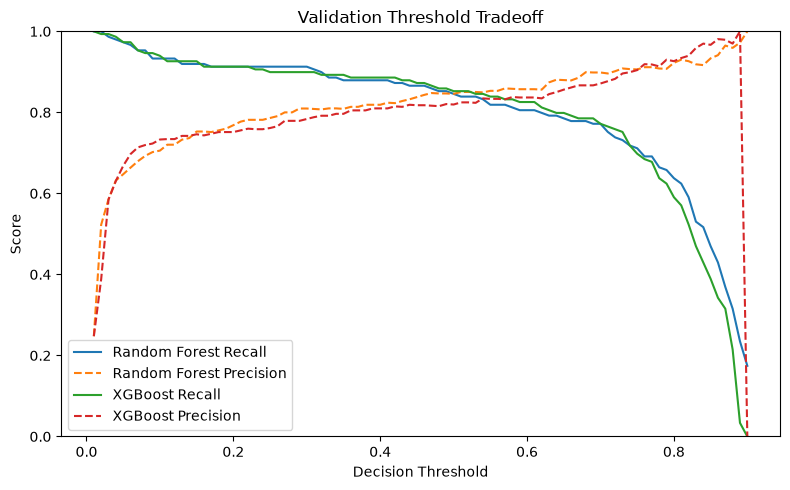

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\figures\final_model_threshold_tradeoff.png


In [9]:
figure, axis = plt.subplots(
    figsize=(8, 5)
)

for model_name in candidate_objects:

    model_data = threshold_results[
        threshold_results["model"] == model_name
    ]

    axis.plot(
        model_data["threshold"],
        model_data["recall"],
        label=f"{model_name} Recall",
    )

    axis.plot(
        model_data["threshold"],
        model_data["precision"],
        linestyle="--",
        label=f"{model_name} Precision",
    )

axis.set_title(
    "Validation Threshold Tradeoff"
)

axis.set_xlabel(
    "Decision Threshold"
)

axis.set_ylabel(
    "Score"
)

axis.set_ylim(
    0,
    1,
)

axis.legend()
plt.tight_layout()

threshold_figure = (
    FIGURES_DIR
    / "final_model_threshold_tradeoff.png"
)

plt.savefig(
    threshold_figure,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", threshold_figure)

## 9. Freeze the final model and threshold

The final candidate is selected using the internal validation results.

Primary selection criterion:

- highest F2

Tie breakers:

1. higher recall
2. higher F1
3. higher PR AUC

After this point, the model family, hyperparameters, calibration method, predictors, and decision threshold are frozen.

In [10]:
selected = candidate_summary.iloc[0]

FINAL_MODEL_NAME = selected["model"]
FINAL_THRESHOLD = float(
    selected["selected_threshold"]
)

BEST_SEARCH = searches[
    FINAL_MODEL_NAME
]

BEST_PIPELINE = BEST_SEARCH.best_estimator_

print("FINAL MODEL:", FINAL_MODEL_NAME)
print("FINAL THRESHOLD:", FINAL_THRESHOLD)
print("FINAL PARAMETERS:")
print(BEST_SEARCH.best_params_)

print("\nValidation selection metrics:")
display(
    candidate_summary.iloc[[0]].round(4)
)

FINAL MODEL: Random Forest
FINAL THRESHOLD: 0.29
FINAL PARAMETERS:
{'model__n_estimators': 500, 'model__min_samples_leaf': 3, 'model__max_features': 0.7, 'model__max_depth': 12, 'model__class_weight': {0: 1, 1: 3}}

Validation selection metrics:


,model,selected_threshold,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,false_negatives,false_positives
0,Random Forest,0.29,0.9252,0.8095,0.9128,0.858,0.8901,0.9717,0.9141,13,32


## 10. Refit the frozen model on the full training set

The selected hyperparameters and calibration approach are now fixed.

The final calibrated model is refitted using all 3,008 training students.

No further model or threshold changes are allowed after this step.

In [11]:
final_calibrated_model = CalibratedClassifierCV(
    estimator=clone(BEST_PIPELINE),
    method="sigmoid",
    cv=5,
    ensemble=False,
)

final_calibrated_model.fit(
    X_train,
    y_train,
)

print(
    "Frozen calibrated model refitted on full training data."
)

Frozen calibrated model refitted on full training data.


## 11. Final held out test evaluation

The frozen calibrated model and frozen threshold are now applied to the held out test set.

These results are the final predictive performance results for the selected model.

In [12]:
test_probabilities = final_calibrated_model.predict_proba(
    X_test
)[:, 1]

test_predictions = (
    test_probabilities >= FINAL_THRESHOLD
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1],
).ravel()

final_test_metrics = pd.DataFrame([{
    "model": FINAL_MODEL_NAME,
    "threshold": FINAL_THRESHOLD,
    "accuracy": accuracy_score(
        y_test,
        test_predictions,
    ),
    "precision": precision_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
    "f1": f1_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
    "f2": fbeta_score(
        y_test,
        test_predictions,
        beta=2,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        test_probabilities,
    ),
    "pr_auc": average_precision_score(
        y_test,
        test_probabilities,
    ),
    "brier_score": brier_score_loss(
        y_test,
        test_probabilities,
    ),
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp),
}])

display(
    final_test_metrics.round(4)
)

,model,threshold,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,brier_score,true_negatives,false_positives,false_negatives,true_positives
0,Random Forest,0.29,0.9043,0.7556,0.9091,0.8252,0.8736,0.969,0.902,0.0623,510,55,17,170


## 12. Final confusion matrix

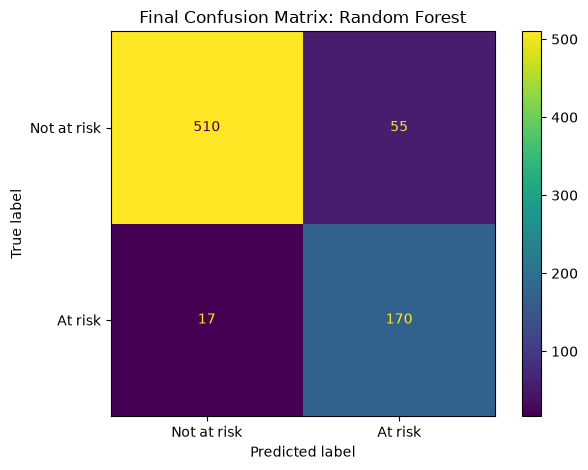

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\figures\final_model_confusion_matrix.png


In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=[0, 1],
    display_labels=[
        "Not at risk",
        "At risk",
    ],
    values_format="d",
)

plt.title(
    f"Final Confusion Matrix: {FINAL_MODEL_NAME}"
)

plt.tight_layout()

confusion_figure = (
    FIGURES_DIR
    / "final_model_confusion_matrix.png"
)

plt.savefig(
    confusion_figure,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", confusion_figure)

## 13. Gender fairness evaluation

Gender was never used as a model predictor.

The held out test predictions are evaluated separately by gender.

The main fairness indicators are:

- recall
- false negative rate
- false positive rate

Accuracy, precision, F1, predicted at risk rate, prevalence, and Brier score are also reported for context.

In [14]:
fairness_frame = pd.DataFrame({
    "gender": fairness_test["gender"].astype("string").to_numpy(),
    "actual": np.asarray(y_test),
    "predicted": test_predictions,
    "probability": test_probabilities,
})

fairness_rows = []

for gender, group in fairness_frame.groupby(
    "gender",
    dropna=False,
):

    tn_g, fp_g, fn_g, tp_g = confusion_matrix(
        group["actual"],
        group["predicted"],
        labels=[0, 1],
    ).ravel()

    fairness_rows.append({
        "gender": str(gender),
        "support": len(group),
        "actual_at_risk_rate": group["actual"].mean(),
        "predicted_at_risk_rate": group["predicted"].mean(),
        "accuracy": accuracy_score(
            group["actual"],
            group["predicted"],
        ),
        "precision": precision_score(
            group["actual"],
            group["predicted"],
            zero_division=0,
        ),
        "recall": recall_score(
            group["actual"],
            group["predicted"],
            zero_division=0,
        ),
        "f1": f1_score(
            group["actual"],
            group["predicted"],
            zero_division=0,
        ),
        "false_positive_rate": (
            fp_g / (fp_g + tn_g)
            if (fp_g + tn_g) > 0
            else np.nan
        ),
        "false_negative_rate": (
            fn_g / (fn_g + tp_g)
            if (fn_g + tp_g) > 0
            else np.nan
        ),
        "brier_score": brier_score_loss(
            group["actual"],
            group["probability"],
        ),
    })

fairness_results = pd.DataFrame(
    fairness_rows
)

display(
    fairness_results.round(4)
)

# Primary gender fairness comparison:
# Female versus Male only

female_row = fairness_results[
    fairness_results["gender"].str.lower() == "female"
]

male_row = fairness_results[
    fairness_results["gender"].str.lower() == "male"
]

if len(female_row) == 1 and len(male_row) == 1:

    female_recall = float(
        female_row["recall"].iloc[0]
    )

    male_recall = float(
        male_row["recall"].iloc[0]
    )

    female_fnr = float(
        female_row["false_negative_rate"].iloc[0]
    )

    male_fnr = float(
        male_row["false_negative_rate"].iloc[0]
    )

    female_fpr = float(
        female_row["false_positive_rate"].iloc[0]
    )

    male_fpr = float(
        male_row["false_positive_rate"].iloc[0]
    )

    recall_gap = abs(
        female_recall - male_recall
    )

    fnr_gap = abs(
        female_fnr - male_fnr
    )

    fpr_gap = abs(
        female_fpr - male_fpr
    )

    print(
        "Female vs Male recall gap:",
        round(recall_gap, 4),
    )

    print(
        "Female vs Male false negative rate gap:",
        round(fnr_gap, 4),
    )

    print(
        "Female vs Male false positive rate gap:",
        round(fpr_gap, 4),
    )

else:
    print(
        "Female and Male groups were not both available "
        "for the primary fairness comparison."
    )

,gender,support,actual_at_risk_rate,predicted_at_risk_rate,accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,brier_score
0,Female,223,0.2556,0.3184,0.8834,0.7183,0.8947,0.7969,0.1205,0.1053,0.0724
1,Male,510,0.2373,0.2843,0.9098,0.7586,0.9091,0.8271,0.0900,0.0909,0.0597
2,Not Disclosed,19,0.4737,0.4737,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0138


Female vs Male recall gap: 0.0144
Female vs Male false negative rate gap: 0.0144
Female vs Male false positive rate gap: 0.0305


## 14. Save the final model and essential results

Only the objects required for later notebooks and thesis reporting are saved.

In [15]:
MODEL_FILE = (
    RESULTS_DIR
    / "final_calibrated_model.joblib"
)

METADATA_FILE = (
    RESULTS_DIR
    / "final_model_metadata.json"
)

SELECTION_FILE = (
    RESULTS_DIR
    / "candidate_validation_results.csv"
)

TEST_FILE = (
    RESULTS_DIR
    / "final_test_metrics.csv"
)

FAIRNESS_FILE = (
    RESULTS_DIR
    / "gender_fairness_metrics.csv"
)

joblib.dump(
    final_calibrated_model,
    MODEL_FILE,
)

candidate_summary.to_csv(
    SELECTION_FILE,
    index=False,
)

final_test_metrics.to_csv(
    TEST_FILE,
    index=False,
)

fairness_results.to_csv(
    FAIRNESS_FILE,
    index=False,
)

metadata = {
    "final_model": FINAL_MODEL_NAME,
    "final_threshold": FINAL_THRESHOLD,
    "calibration_method": "sigmoid",
    "raw_predictor_count": int(X_train.shape[1]),
    "numeric_predictor_count": len(NUMERIC_FEATURES),
    "categorical_predictor_count": len(CATEGORICAL_FEATURES),
    "selected_features": list(X_train.columns),
    "best_parameters": BEST_SEARCH.best_params_,
    "selection_metric": "F2 on internal validation set",
    "random_state": RANDOM_STATE,
    "cv_random_state": CV_RANDOM_STATE,
}

with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        metadata,
        file,
        indent=2,
        default=str,
    )

print("Saved:", MODEL_FILE)
print("Saved:", METADATA_FILE)
print("Saved:", SELECTION_FILE)
print("Saved:", TEST_FILE)
print("Saved:", FAIRNESS_FILE)

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\final_model\final_calibrated_model.joblib
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\final_model\final_model_metadata.json
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\final_model\candidate_validation_results.csv
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\final_model\final_test_metrics.csv
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\final_model\gender_fairness_metrics.csv


15.


In [16]:
from scipy.stats import binomtest, chi2
from sklearn.metrics import roc_auc_score, average_precision_score

# 15.1 Identify the runner-up and refit it on the full training set,
# exactly as the frozen model was refit in Section 10.

RUNNER_UP_NAME = [
    name for name in candidate_objects if name != FINAL_MODEL_NAME
][0]

runner_up_row = candidate_summary[
    candidate_summary["model"] == RUNNER_UP_NAME
].iloc[0]

RUNNER_UP_THRESHOLD = float(runner_up_row["selected_threshold"])

runner_up_best_pipeline = searches[RUNNER_UP_NAME].best_estimator_

runner_up_calibrated_model = CalibratedClassifierCV(
    estimator=clone(runner_up_best_pipeline),
    method="sigmoid",
    cv=5,
    ensemble=False,
)

runner_up_calibrated_model.fit(
    X_train,
    y_train,
)

runner_up_test_probabilities = runner_up_calibrated_model.predict_proba(
    X_test
)[:, 1]

runner_up_test_predictions = (
    runner_up_test_probabilities >= RUNNER_UP_THRESHOLD
).astype(int)

print("Runner-up model:", RUNNER_UP_NAME)
print("Runner-up threshold:", RUNNER_UP_THRESHOLD)

Runner-up model: XGBoost
Runner-up threshold: 0.22


In [17]:
# 15.2 McNemar's test on paired test-set decisions.
# Compares the two models' correctness on the SAME 752 students.

y_test_array = y_test.to_numpy()

final_correct = (test_predictions == y_test_array)
runner_up_correct = (runner_up_test_predictions == y_test_array)


def mcnemar_test(correct_final, correct_runner_up):
    only_final_wrong = int(
        np.sum((~correct_final) & correct_runner_up)
    )
    only_runner_up_wrong = int(
        np.sum(correct_final & (~correct_runner_up))
    )
    n_discordant = only_final_wrong + only_runner_up_wrong

    if n_discordant == 0:
        return {
            "only_final_wrong": 0,
            "only_runner_up_wrong": 0,
            "discordant_pairs": 0,
            "chi2_stat": np.nan,
            "chi2_p_value": np.nan,
            "exact_p_value": np.nan,
        }

    chi2_stat = (
        (abs(only_final_wrong - only_runner_up_wrong) - 1) ** 2
    ) / n_discordant

    chi2_p_value = 1 - chi2.cdf(chi2_stat, df=1)

    exact_p_value = binomtest(
        min(only_final_wrong, only_runner_up_wrong),
        n_discordant,
        0.5,
    ).pvalue

    return {
        "only_final_wrong": only_final_wrong,
        "only_runner_up_wrong": only_runner_up_wrong,
        "discordant_pairs": n_discordant,
        "chi2_stat": chi2_stat,
        "chi2_p_value": chi2_p_value,
        "exact_p_value": exact_p_value,
    }


mcnemar_result = mcnemar_test(
    final_correct,
    runner_up_correct,
)

print(f"\nMcNemar's test: {FINAL_MODEL_NAME} vs {RUNNER_UP_NAME}")
for key, value in mcnemar_result.items():
    print(f"  {key}: {value}")


McNemar's test: Random Forest vs XGBoost
  only_final_wrong: 15
  only_runner_up_wrong: 19
  discordant_pairs: 34
  chi2_stat: 0.2647058823529412
  chi2_p_value: 0.6069054272179508
  exact_p_value: 0.6075913612730801


In [18]:
# 15.3 Paired bootstrap comparison of ROC AUC and PR AUC.
# Threshold-free, so it complements McNemar's test above.

def paired_bootstrap_metric_diff(
    y_true,
    probs_a,
    probs_b,
    metric_func,
    n_boot=2000,
    random_state=RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    probs_a = np.asarray(probs_a)
    probs_b = np.asarray(probs_b)
    n = len(y_true)

    observed_diff = metric_func(y_true, probs_a) - metric_func(y_true, probs_b)

    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        y_sample = y_true[idx]

        if y_sample.sum() == 0 or y_sample.sum() == n:
            continue  # skip degenerate resamples with only one class

        diffs.append(
            metric_func(y_sample, probs_a[idx])
            - metric_func(y_sample, probs_b[idx])
        )

    diffs = np.array(diffs)
    ci_lower, ci_upper = np.percentile(diffs, [2.5, 97.5])
    p_value = min(
        2 * min((diffs <= 0).mean(), (diffs >= 0).mean()),
        1.0,
    )

    return {
        "observed_diff": observed_diff,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "bootstrap_p_value": p_value,
    }


roc_auc_comparison = paired_bootstrap_metric_diff(
    y_test_array,
    test_probabilities,
    runner_up_test_probabilities,
    roc_auc_score,
)

pr_auc_comparison = paired_bootstrap_metric_diff(
    y_test_array,
    test_probabilities,
    runner_up_test_probabilities,
    average_precision_score,
)

print(f"\nROC AUC difference ({FINAL_MODEL_NAME} - {RUNNER_UP_NAME}):")
for key, value in roc_auc_comparison.items():
    print(f"  {key}: {value:.4f}")

print(f"\nPR AUC difference ({FINAL_MODEL_NAME} - {RUNNER_UP_NAME}):")
for key, value in pr_auc_comparison.items():
    print(f"  {key}: {value:.4f}")


ROC AUC difference (Random Forest - XGBoost):
  observed_diff: 0.0034
  ci_lower: -0.0017
  ci_upper: 0.0085
  bootstrap_p_value: 0.1870

PR AUC difference (Random Forest - XGBoost):
  observed_diff: -0.0002
  ci_lower: -0.0220
  ci_upper: 0.0179
  bootstrap_p_value: 0.9810


In [19]:
# 15.4 Save results for Chapter 5.5 (Statistical Significance).

significance_results = {
    "final_model": FINAL_MODEL_NAME,
    "runner_up_model": RUNNER_UP_NAME,
    "runner_up_threshold": RUNNER_UP_THRESHOLD,
    "mcnemar_test": mcnemar_result,
    "roc_auc_bootstrap": roc_auc_comparison,
    "pr_auc_bootstrap": pr_auc_comparison,
}

SIGNIFICANCE_FILE = (
    RESULTS_DIR
    / "statistical_significance_results.json"
)

with open(
    SIGNIFICANCE_FILE,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        significance_results,
        file,
        indent=2,
        default=str,
    )

print("\nSaved:", SIGNIFICANCE_FILE)


Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\final_model\statistical_significance_results.json


## Notebook 03_C complete

The final model is now frozen.

Notebook 04 should load:

- `final_calibrated_model.joblib`
- `final_model_metadata.json`